## Importación de Librerías y Configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

## Creación y Visualización de los Datos

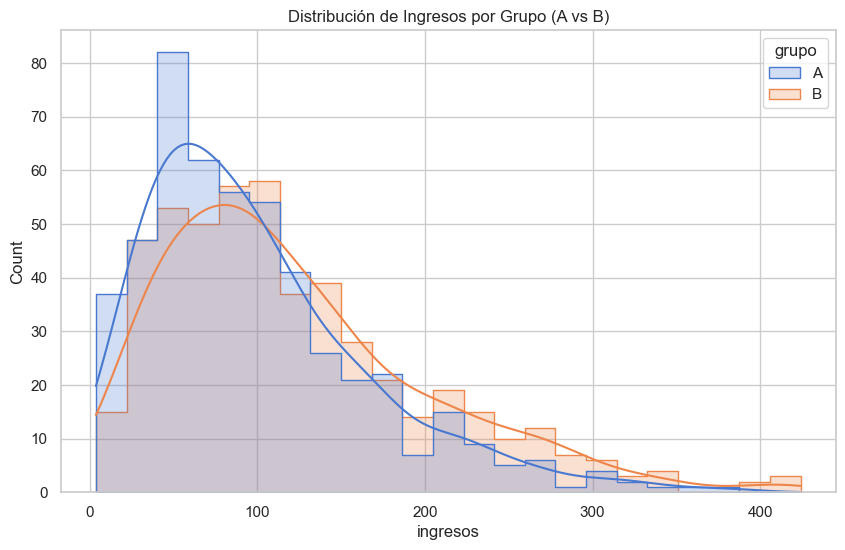

Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
grupo,,,,,,,,
A,500.0,99.169821,67.188324,6.583484,50.225711,84.351660,130.411731,384.257299
B,500.0,121.820206,79.279357,3.831250,61.846056,102.327114,159.946158,424.053562


In [3]:
np.random.seed(42)
grupo_a = np.random.gamma(shape=2, scale=50, size=500)
grupo_b = np.random.gamma(shape=2.2, scale=52, size=500)
df_ab = pd.DataFrame({
    'ingresos': np.concatenate([grupo_a, grupo_b]),
    'grupo': ['A'] * 500 + ['B'] * 500
})
plt.figure(figsize=(10, 6))
sns.histplot(data=df_ab, x='ingresos', hue='grupo', kde=True, element="step")
plt.title('Distribución de Ingresos por Grupo (A vs B)')
plt.show()
print("Estadísticos descriptivos:")
display(df_ab.groupby('grupo')['ingresos'].describe())

## Limpieza y Verificación de Supuestos

In [4]:
_, p_norm_a = stats.shapiro(grupo_a)
_, p_norm_b = stats.shapiro(grupo_b)
print(f"P-value Normalidad Grupo A: {p_norm_a:.4f}")
print(f"P-value Normalidad Grupo B: {p_norm_b:.4f}")
_, p_levene = stats.levene(grupo_a, grupo_b)
print(f"P-value Homogeneidad de Varianza: {p_levene:.4f}")

P-value Normalidad Grupo A: 0.0000
P-value Normalidad Grupo B: 0.0000
P-value Homogeneidad de Varianza: 0.0021


## Ejecución del Test Estadístico

In [5]:
if p_norm_a < 0.05 or p_norm_b < 0.05:
    stat, p_value = stats.mannwhitneyu(grupo_a, grupo_b)
    test_name = "U de Mann-Whitney"
else:
    stat, p_value = stats.ttest_ind(grupo_a, grupo_b)
    test_name = "T-Test"
print(f"Prueba utilizada: {test_name}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Resultado: Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA. Se recomienda implementar el cambio.")
else:
    print("Resultado: No hay diferencia significativa. Mantener la versión actual.")

Prueba utilizada: U de Mann-Whitney
P-value: 0.0000
Resultado: Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA. Se recomienda implementar el cambio.


## Análisis de Importancia de Características

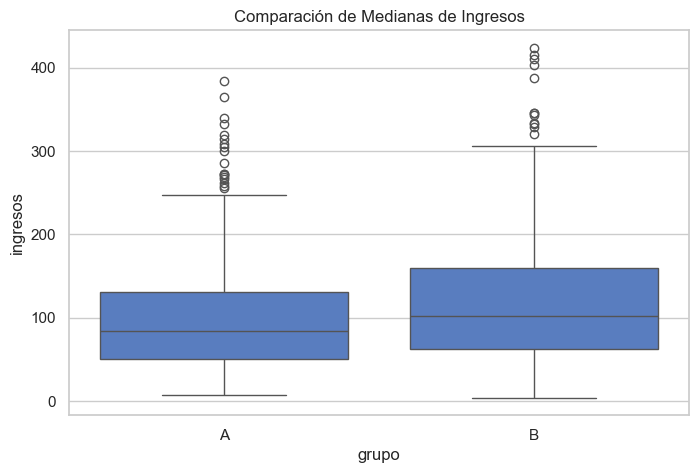

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='grupo', y='ingresos', data=df_ab)
plt.title('Comparación de Medianas de Ingresos')
plt.show()

## Conclusiones

* **Distribución:** Ambos grupos (A y B) presentan una distribución con sesgo positivo (cola larga hacia la derecha), lo cual es típico en datos de ingresos.

* **Comparación de Medias:** El Grupo B tiene una media superior (121.82) comparada con la del Grupo A (99.17).

* **Dispersión:** El Grupo B también muestra una mayor variabilidad (desviación estándar de 79.28 frente a 67.19 del Grupo A) y valores máximos más altos.

* **El cambio es efectivo:** Existe una diferencia real y comprobada entre el Grupo A y el Grupo B. No se debe al azar.

Superioridad del Grupo B:** Los indicadores (media, mediana en el boxplot y percentiles) muestran que el Grupo B genera mayores ingresos de manera consistente.

* **Recomendación de Negocio:** Tal como indica el output del código, se recomienda implementar el cambio (la versión B), ya que ha demostrado mejorar la métrica de ingresos de forma sólida.

* **Nota técnica:** El uso de la U de Mann-Whitney fue la elección correcta aquí, ya que el T-Test habría dado resultados poco fiables debido a la falta de normalidad y la diferencia de varianzas detectada.